## Global Import and Environment Setup

In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline
sys.path.append(os.path.abspath(os.path.join('..')))
from src.data.ingestion import fetch_synchronized_data

## Data Ingestion

In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))
from src.data.ingestion import fetch_synchronized_data
import pandas as pd

tickers = ["SPY", "QQQ", "0005.HK", "EPHE", "GLD"]

raw_prices = fetch_synchronized_data(tickers, start="2023-01-01")

if not raw_prices.empty:
    print(f"Ingestion Successful.")
    print(f"Matrix Dimensions: {raw_prices.shape[0]} Observations x {raw_prices.shape[1]} Features")
    display(raw_prices.head())
else:
    print("Ingestion Failed. Check network or ticker symbols.")

Ingesting Proxy Tickers: ['SPY', 'QQQ', '0005.HK', 'EPHE', 'GLD']
Synch complete. Rows: 799 | Features 5
Ingestion Successful.
Matrix Dimensions: 799 Observations x 5 Features


Ticker,0005.HK,EPHE,GLD,QQQ,SPY
Date,,,,,
2023-01-03 00:00:00+00:00,37.904926,24.904282,171.059998,259.468750,365.072113
2023-01-04 00:00:00+00:00,38.916763,25.683126,172.669998,260.704803,367.890472
2023-01-05 00:00:00+00:00,39.889690,25.683126,170.520004,256.623718,363.691589
2023-01-06 00:00:00+00:00,40.629101,25.861416,173.710007,263.706909,372.031830
2023-01-09 00:00:00+00:00,41.485271,26.246145,174.100006,265.413879,371.820953


## Growth and Scale Diagnostics

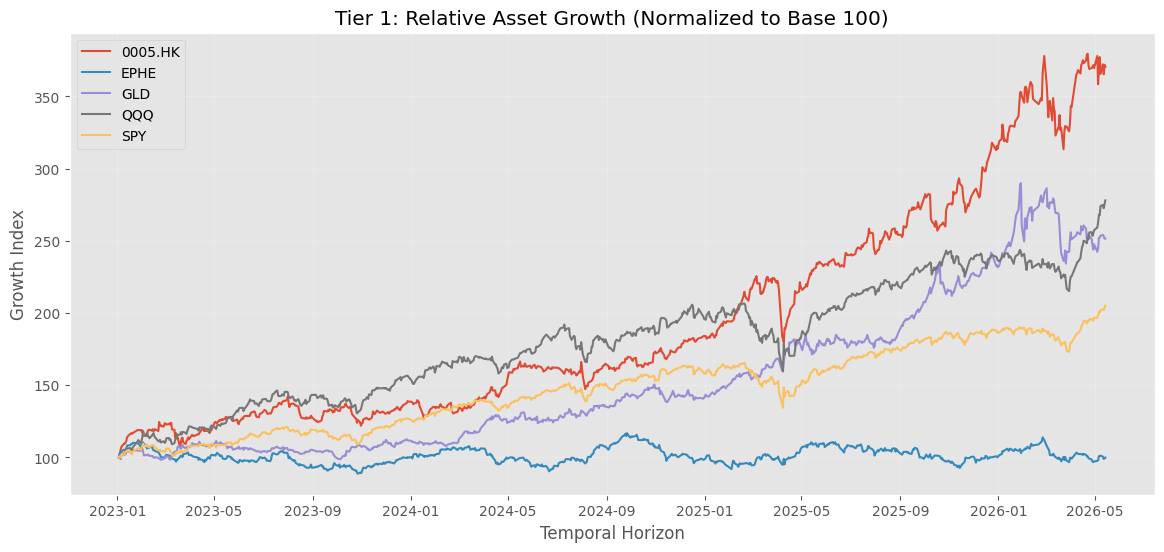

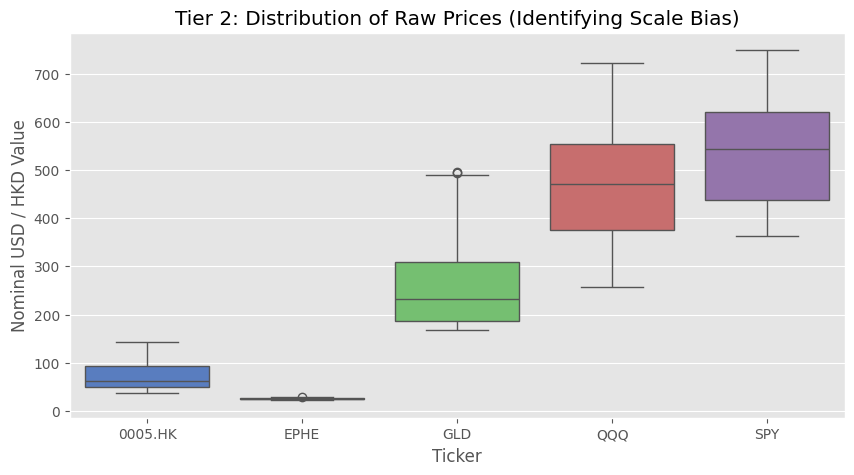

In [3]:
normalized_prices = (raw_prices / raw_prices.iloc[0]) * 100

plt.figure(figsize=(14, 6))
for column in normalized_prices.columns:
    plt.plot(normalized_prices.index, normalized_prices[column], label=column, lw=1.5)

plt.title("Tier 1: Relative Asset Growth (Normalized to Base 100)")
plt.xlabel("Temporal Horizon")
plt.ylabel("Growth Index")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=raw_prices, palette="muted")
plt.title("Tier 2: Distribution of Raw Prices (Identifying Scale Bias)")
plt.ylabel("Nominal USD / HKD Value")
plt.show()

**Output: Tier 1** 
The base 100 normalization serves as the standardized layer to resolve the magnitude bias, it completely solves the problem of having a higher asset value of 365 on SPY and low nominal asset like EPHE at 24, with this distinction, we can calculate the cumulative performance on an equal percentage basis. While this plot confirms that 0005.HK surpass the 5 markets in cumulative return, however the primary take away in my data is that it remains Non-Stationary. With this, I propose a Log-Return transformation to stabilize the mean and variance before clustering. 

**Output: Tier 2** 
Distribution of Raw Prices EDA reveals that the scale variance across different markets are not the same, and does not operate on the same power level. The visual tells that for SPY and QQQ occupies a higher coordinate space on the y-axis compared to the other markets. This simply means that the market are not on the same power level. This will be a problem in ML if left unaddress, as the euclidean distance will be dominated by SPY and QQQ. 

## Correlation Mapping

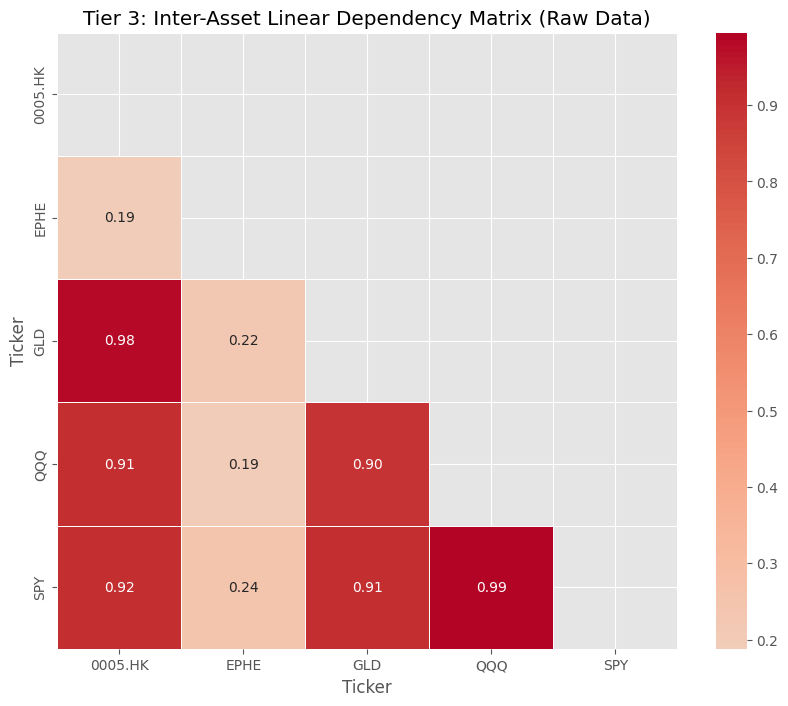

In [ ]:
correlation_matrix = raw_prices.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix, 
    mask=mask, 
    annot=True, 
    cmap='coolwarm', 
    center=0,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Tier 3: Inter-Asset Linear Dependency Matrix (Raw Data)")
plt.show()

**Output:**
This visual simply tells how much of an overlap exists in the markets / sensors. As you can see the intersection of SPY and QQQ highly suggests that the two assets are almost identical in this timeframe, keeping this may lead to overfitting or biased metrics. As you can see GLD, QQQ, and SPY show a correlation of > 0.90 his tells that the market belong in a single global risk cluster while the rest of the market shows a very low correlation indicating that it moves indepdently. 
